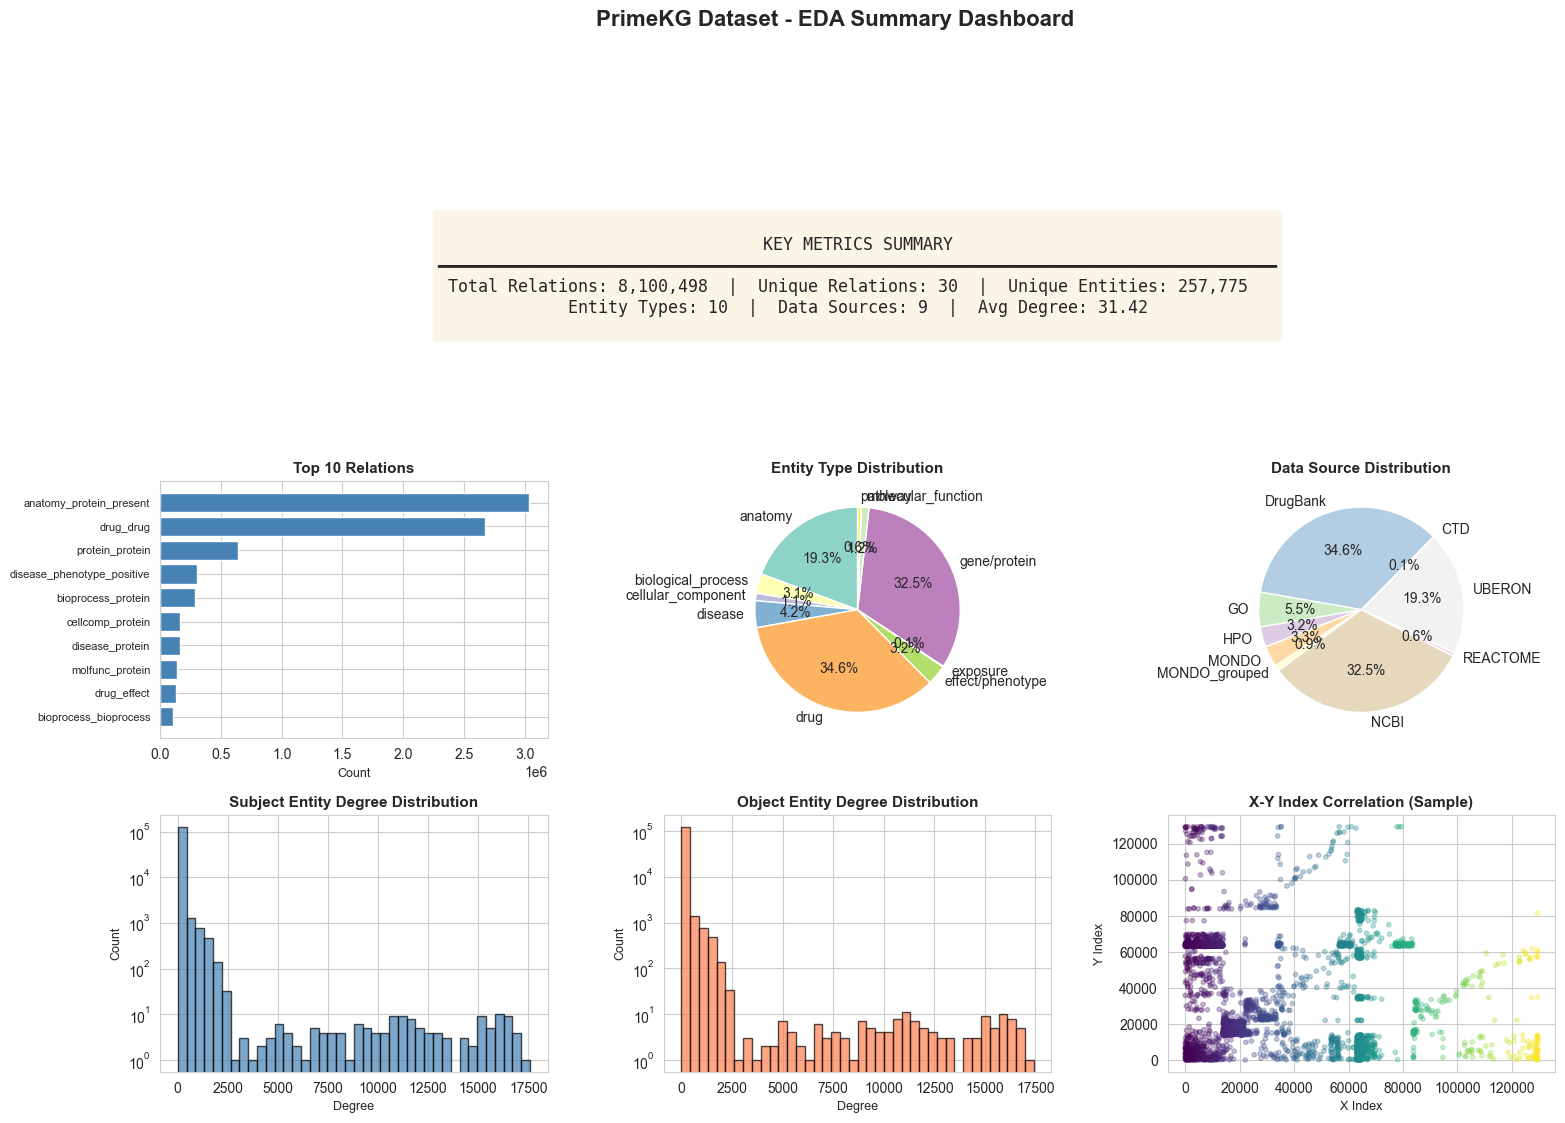


✓ EDA Complete! Dashboard generated successfully.


In [11]:
# Create a comprehensive dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Key Metrics (text summary)
ax1 = fig.add_subplot(gs[0, :])
ax1.axis('off')
metrics_text = f"""
KEY METRICS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Relations: {len(df):,}  |  Unique Relations: {df['relation'].nunique()}  |  Unique Entities: {unique_x_ids + unique_y_ids:,}  
Entity Types: {len(set(x_type_counts.index) | set(y_type_counts.index))}  |  Data Sources: {len(set(x_source_counts.index) | set(y_source_counts.index))}  |  Avg Degree: {len(df) / (unique_x_ids + unique_y_ids):.2f}
"""
ax1.text(0.5, 0.5, metrics_text, transform=ax1.transAxes, fontsize=12, 
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3), family='monospace')

# 2. Top 10 Relations
ax2 = fig.add_subplot(gs[1, 0])
top_10_relations = relation_counts.head(10)
ax2.barh(range(len(top_10_relations)), top_10_relations.values, color='steelblue')
ax2.set_yticks(range(len(top_10_relations)))
ax2.set_yticklabels(top_10_relations.index, fontsize=8)
ax2.set_xlabel('Count', fontsize=9)
ax2.set_title('Top 10 Relations', fontsize=11, fontweight='bold')
ax2.invert_yaxis()

# 3. Entity Type Distribution
ax3 = fig.add_subplot(gs[1, 1])
all_types = pd.concat([x_type_counts, y_type_counts]).groupby(level=0).sum()
colors = plt.cm.Set3(np.linspace(0, 1, len(all_types)))
ax3.pie(all_types.values, labels=all_types.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Entity Type Distribution', fontsize=11, fontweight='bold')

# 4. Data Source Distribution
ax4 = fig.add_subplot(gs[1, 2])
all_sources = pd.concat([x_source_counts, y_source_counts]).groupby(level=0).sum()
colors_src = plt.cm.Pastel1(np.linspace(0, 1, len(all_sources)))
wedges, texts, autotexts = ax4.pie(all_sources.values, labels=all_sources.index, autopct='%1.1f%%', 
                                     colors=colors_src, startangle=45)
ax4.set_title('Data Source Distribution', fontsize=11, fontweight='bold')

# 5. Subject Degree Distribution
ax5 = fig.add_subplot(gs[2, 0])
ax5.hist(x_degree, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
ax5.set_xlabel('Degree', fontsize=9)
ax5.set_ylabel('Count', fontsize=9)
ax5.set_title('Subject Entity Degree Distribution', fontsize=11, fontweight='bold')
ax5.set_yscale('log')

# 6. Object Degree Distribution
ax6 = fig.add_subplot(gs[2, 1])
ax6.hist(y_degree, bins=40, color='coral', alpha=0.7, edgecolor='black')
ax6.set_xlabel('Degree', fontsize=9)
ax6.set_ylabel('Count', fontsize=9)
ax6.set_title('Object Entity Degree Distribution', fontsize=11, fontweight='bold')
ax6.set_yscale('log')

# 7. Index Distribution Scatter
ax7 = fig.add_subplot(gs[2, 2])
# Sample for visualization
sample_indices = np.random.choice(len(df), size=min(5000, len(df)), replace=False)
ax7.scatter(df.iloc[sample_indices]['x_index'], df.iloc[sample_indices]['y_index'], 
           alpha=0.3, s=10, c=df.iloc[sample_indices]['x_index'], cmap='viridis')
ax7.set_xlabel('X Index', fontsize=9)
ax7.set_ylabel('Y Index', fontsize=9)
ax7.set_title('X-Y Index Correlation (Sample)', fontsize=11, fontweight='bold')

plt.suptitle('PrimeKG Dataset - EDA Summary Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\n✓ EDA Complete! Dashboard generated successfully.")

## 9. Visual Summary Dashboard

In [10]:
# Comprehensive Summary
summary_stats = {
    'Total Edges': len(df),
    'Unique Relations': df['relation'].nunique(),
    'Unique Subject Entities': unique_x_ids,
    'Unique Object Entities': unique_y_ids,
    'Entity Types': len(set(x_type_counts.index) | set(y_type_counts.index)),
    'Data Sources': len(set(x_source_counts.index) | set(y_source_counts.index)),
    'Most Common Relation': relation_counts.index[0],
    'Most Common Relation Count': relation_counts.values[0],
    'Most Connected Subject': df.groupby('x_name').size().idxmax(),
    'Most Connected Subject Edges': df.groupby('x_name').size().max(),
    'Average Edges per Entity': len(df) / (unique_x_ids + unique_y_ids),
}

print("=" * 80)
print("KNOWLEDGE GRAPH SUMMARY STATISTICS")
print("=" * 80)
for key, value in summary_stats.items():
    if isinstance(value, (int, float)):
        if value > 1000:
            print(f"{key:.<40} {value:>15,.0f}")
        else:
            print(f"{key:.<40} {value:>15}")
    else:
        print(f"{key:.<40} {value:>15}")

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

print(f"""
1. SCALE: This is a large knowledge graph with {len(df):,} directed edges connecting 
   {unique_x_ids + unique_y_ids:,} unique entities across {df['relation'].nunique()} types of relationships.

2. RELATION DISTRIBUTION: The knowledge graph is dominated by '{relation_counts.index[0]}' 
   relationships ({relation_counts.values[0]:,} edges, {relation_counts.values[0]/len(df)*100:.1f}%), 
   indicating a specific focus area.

3. ENTITY TYPES: The dataset contains {len(set(x_type_counts.index) | set(y_type_counts.index))} types of entities, 
   with '{x_type_counts.index[0]}' being the most common subject type 
   and '{y_type_counts.index[0]}' being the most common object type.

4. DATA SOURCES: Knowledge is sourced from {len(set(x_source_counts.index) | set(y_source_counts.index))} different databases/sources, 
   with '{x_source_counts.index[0]}' being the primary source.

5. CONNECTIVITY: The network has a power-law degree distribution (log-scale histogram), 
   with a few highly-connected hub entities and many weakly-connected entities.

6. GRAPH SPARSITY: The knowledge graph is highly sparse, with only {len(df) / (unique_x_ids * unique_y_ids) * 100:.4f}% 
   of possible edges filled, typical for knowledge graphs.

7. MOST CONNECTED ENTITY: '{summary_stats['Most Connected Subject']}' is the most connected subject 
   with {summary_stats['Most Connected Subject Edges']} connections.
""")

KNOWLEDGE GRAPH SUMMARY STATISTICS
Total Edges.............................       8,100,498
Unique Relations........................              30
Unique Subject Entities.................         130,293
Unique Object Entities..................         127,482
Entity Types............................              10
Data Sources............................               9
Most Common Relation.................... anatomy_protein_present
Most Common Relation Count..............         3036406
Most Connected Subject.................. multi-cellular organism
Most Connected Subject Edges............           17355
Average Edges per Entity................ 31.424684317718942

KEY INSIGHTS

1. SCALE: This is a large knowledge graph with 8,100,498 directed edges connecting 
   257,775 unique entities across 30 types of relationships.

2. RELATION DISTRIBUTION: The knowledge graph is dominated by 'anatomy_protein_present' 
   relationships (3,036,406 edges, 37.5%), 
   indicating a specific 

## 8. Summary and Key Insights

INDEX ANALYSIS
x_index range: 0 to 129374
y_index range: 0 to 129374

Total entries: 8,100,498
Average x_index: 30591.39
Average y_index: 30591.39


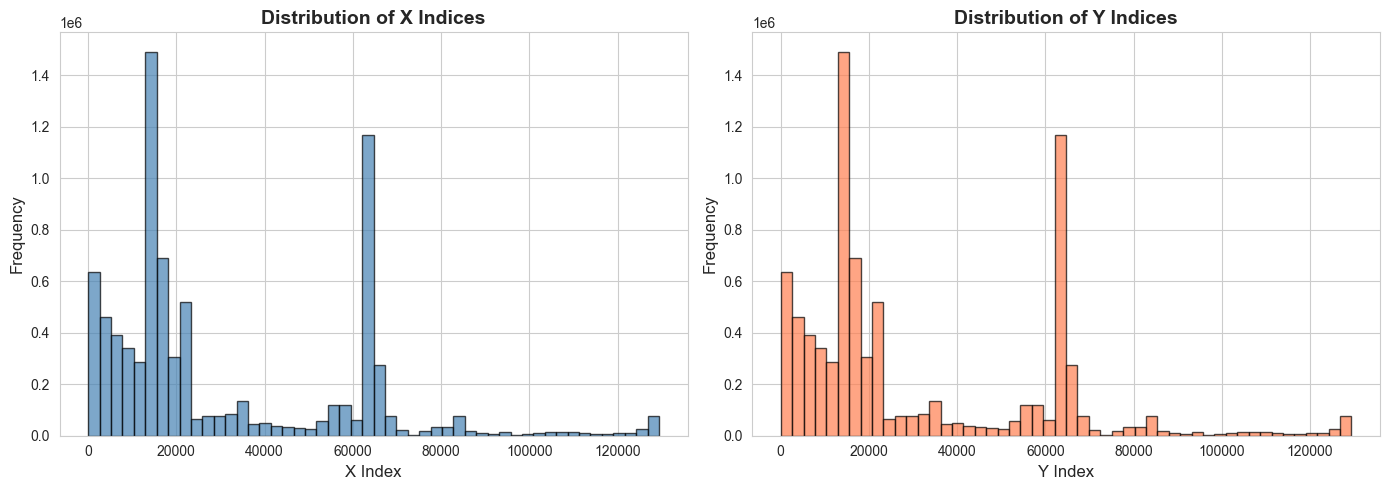

In [12]:
# Analyze indices
print("=" * 80)
print("INDEX ANALYSIS")
print("=" * 80)
print(f"x_index range: {df['x_index'].min()} to {df['x_index'].max()}")
print(f"y_index range: {df['y_index'].min()} to {df['y_index'].max()}")
print(f"\nTotal entries: {len(df):,}")
print(f"Average x_index: {df['x_index'].mean():.2f}")
print(f"Average y_index: {df['y_index'].mean():.2f}")

# Visualize index distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['x_index'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('X Index', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of X Indices', fontsize=14, fontweight='bold')

axes[1].hist(df['y_index'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Y Index', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Y Indices', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Index Analysis

Entity Type Combinations (Top 15):
                x_type              y_type    count
14                drug                drug  2672628
1              anatomy        gene/protein  1538090
27        gene/protein             anatomy  1538090
34        gene/protein        gene/protein   642150
10             disease    effect/phenotype   151510
17    effect/phenotype             disease   151510
28        gene/protein  biological_process   144805
4   biological_process        gene/protein   144805
2   biological_process  biological_process   105772
29        gene/protein  cellular_component    83402
7   cellular_component        gene/protein    83402
30        gene/protein             disease    80411
12             disease        gene/protein    80411
38  molecular_function        gene/protein    69530
35        gene/protein  molecular_function    69530


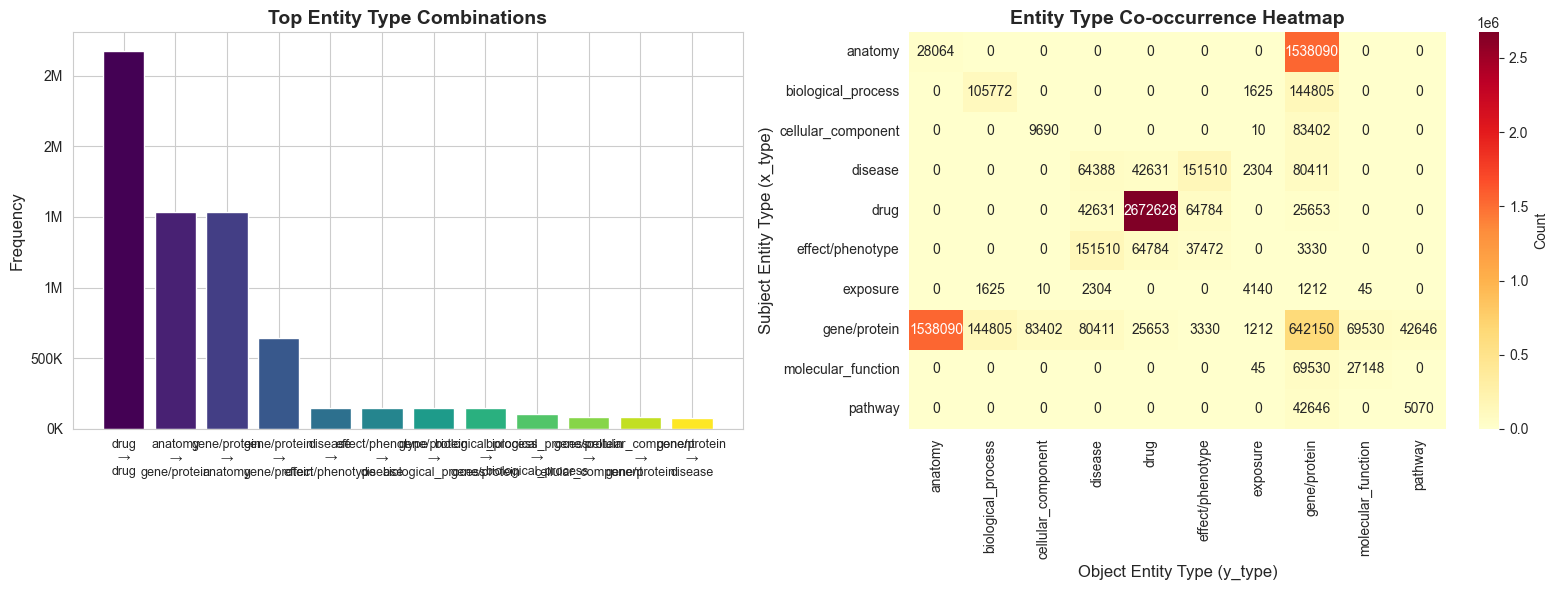

In [13]:
# Analyze entity type combinations
entity_type_combinations = df.groupby(['x_type', 'y_type']).size().reset_index(name='count')
entity_type_combinations = entity_type_combinations.sort_values('count', ascending=False)

print("Entity Type Combinations (Top 15):")
print(entity_type_combinations.head(15))

# Visualize entity type combinations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top combinations bar chart
top_combinations = entity_type_combinations.head(12)
combination_labels = [f"{row['x_type']}\n→\n{row['y_type']}" 
                      for _, row in top_combinations.iterrows()]
axes[0].bar(range(len(top_combinations)), top_combinations['count'].values, 
            color=plt.cm.viridis(np.linspace(0, 1, len(top_combinations))))
axes[0].set_xticks(range(len(top_combinations)))
axes[0].set_xticklabels(combination_labels, fontsize=9)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Top Entity Type Combinations', fontsize=14, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))

# Heatmap of entity type combinations
pivot_table = df.groupby(['x_type', 'y_type']).size().unstack(fill_value=0)
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Entity Type Co-occurrence Heatmap', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Object Entity Type (y_type)', fontsize=12)
axes[1].set_ylabel('Subject Entity Type (x_type)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# Analyze relation patterns by entity types
relation_entity_pattern = df.groupby(['relation', 'x_type', 'y_type']).size().reset_index(name='count')
relation_entity_pattern_sorted = relation_entity_pattern.sort_values('count', ascending=False)

print("Top 15 Relation-Entity Type Patterns:")
print(relation_entity_pattern_sorted.head(15))

# Create a heatmap for top relations and entity type combinations
top_relations_list = df['relation'].value_counts().head(10).index
filtered_df = df[df['relation'].isin(top_relations_list)]

# Create pattern matrix
pattern_matrix = filtered_df.groupby(['relation', 'x_type', 'y_type']).size().unstack(fill_value=0)

print("\nRelation x (X-Type, Y-Type) Matrix:")
print(pattern_matrix.head(10))

## 6. Relation-Entity Type Patterns

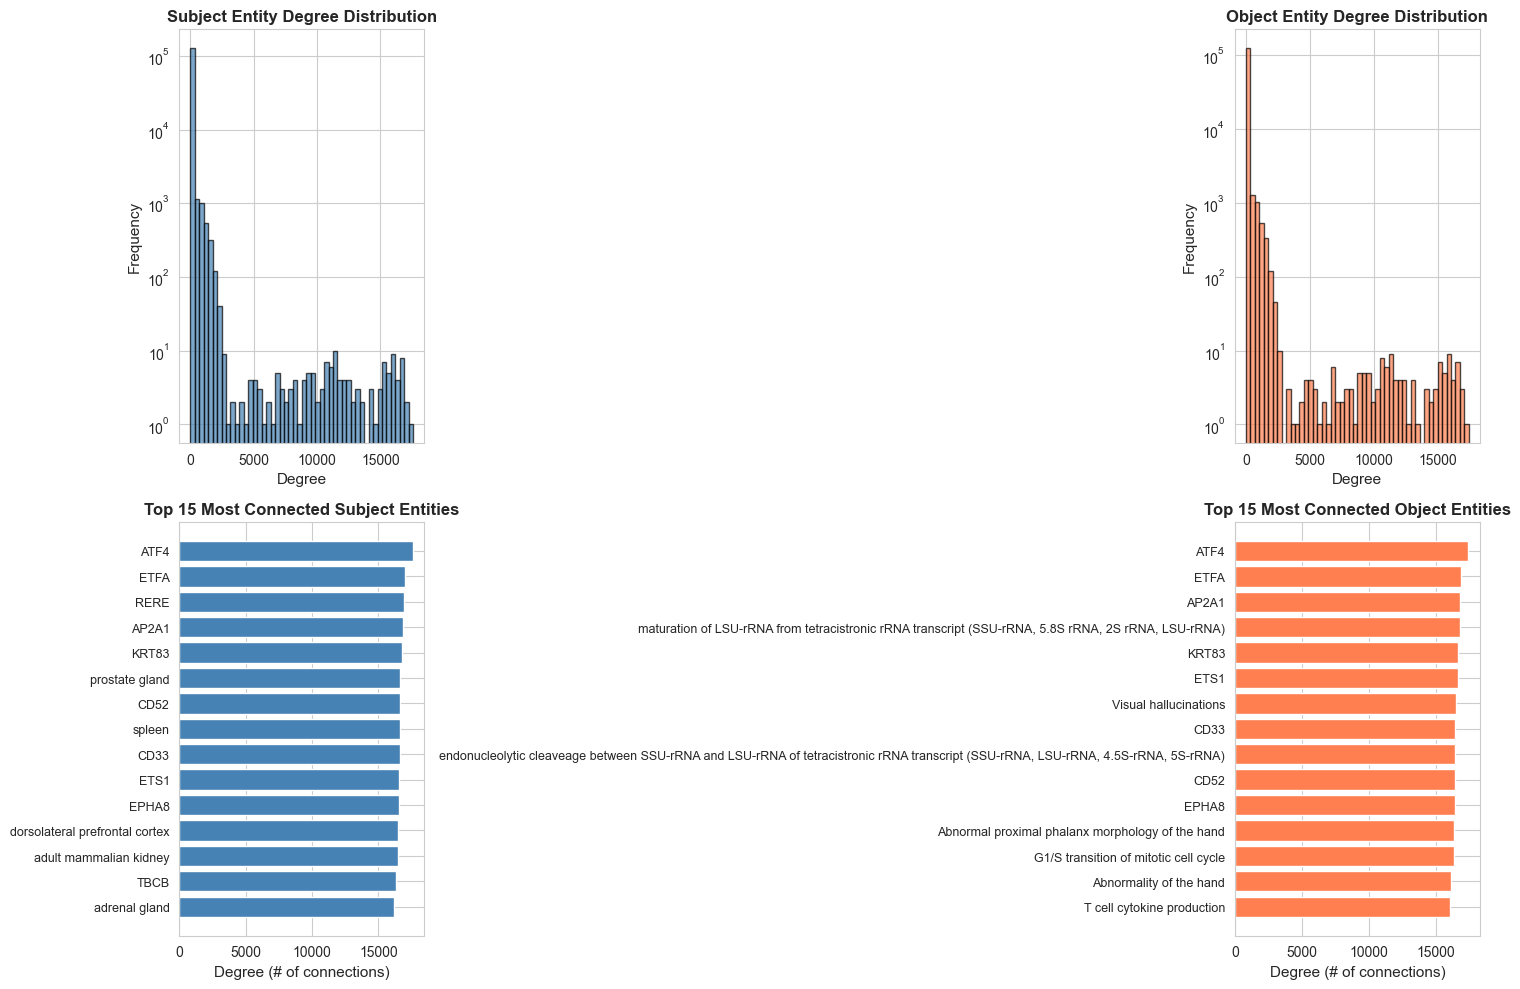

In [7]:
# Visualize degree distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Subject degree histogram
axes[0, 0].hist(x_degree, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Degree', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Subject Entity Degree Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_yscale('log')

# Object degree histogram
axes[0, 1].hist(y_degree, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Degree', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Object Entity Degree Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')

# Top entities by degree (subject)
top_x_degree = x_degree.nlargest(15)
axes[1, 0].barh(range(len(top_x_degree)), top_x_degree.values, color='steelblue')
axes[1, 0].set_yticks(range(len(top_x_degree)))
axes[1, 0].set_yticklabels([df[df['x_id']==idx]['x_name'].iloc[0] for idx in top_x_degree.index], fontsize=9)
axes[1, 0].set_xlabel('Degree (# of connections)', fontsize=11)
axes[1, 0].set_title('Top 15 Most Connected Subject Entities', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# Top entities by degree (object)
top_y_degree = y_degree.nlargest(15)
axes[1, 1].barh(range(len(top_y_degree)), top_y_degree.values, color='coral')
axes[1, 1].set_yticks(range(len(top_y_degree)))
axes[1, 1].set_yticklabels([df[df['y_id']==idx]['y_name'].iloc[0] for idx in top_y_degree.index], fontsize=9)
axes[1, 1].set_xlabel('Degree (# of connections)', fontsize=11)
axes[1, 1].set_title('Top 15 Most Connected Object Entities', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# Network statistics
unique_x_ids = df['x_id'].nunique()
unique_y_ids = df['y_id'].nunique()
unique_x_names = df['x_name'].nunique()
unique_y_names = df['y_name'].nunique()

print("=" * 80)
print("NETWORK STATISTICS")
print("=" * 80)
print(f"Total edges (relations): {len(df):,}")
print(f"Unique subject entities (x_id): {unique_x_ids:,}")
print(f"Unique object entities (y_id): {unique_y_ids:,}")
print(f"Total unique entities: {unique_x_ids + unique_y_ids:,}")
print(f"\nUnique subject names (x_name): {unique_x_names:,}")
print(f"Unique object names (y_name): {unique_y_names:,}")
print(f"\nAverage degree (edges per entity): {len(df) / (unique_x_ids + unique_y_ids):.2f}")
print(f"Sparsity: {(1 - len(df) / (unique_x_ids * unique_y_ids)) * 100:.4f}%")

# Analyze entity degree distribution (how many edges per entity)
x_degree = df.groupby('x_id').size()
y_degree = df.groupby('y_id').size()

print(f"\nSubject entity degree statistics:")
print(x_degree.describe())
print(f"\nObject entity degree statistics:")
print(y_degree.describe())

NETWORK STATISTICS
Total edges (relations): 8,100,498
Unique subject entities (x_id): 130,293
Unique object entities (y_id): 127,482
Total unique entities: 257,775

Unique subject names (x_name): 129,262
Unique object names (y_name): 129,262

Average degree (edges per entity): 31.42
Sparsity: 99.9512%

Subject entity degree statistics:
count    130293.000000
mean         62.171398
std         422.467716
min           1.000000
25%           2.000000
50%           4.000000
75%          25.000000
max       17588.000000
dtype: float64

Object entity degree statistics:
count    127482.000000
mean         63.542288
std         424.517235
min           1.000000
25%           2.000000
50%           4.000000
75%          24.000000
max       17414.000000
dtype: float64


## 5. Entity and Network Statistics

Subject Data Sources (x_source):
x_source
DrugBank         2805696
NCBI             2631229
UBERON           1566154
GO                442027
MONDO             268349
HPO               257096
MONDO_grouped      72895
REACTOME           47716
CTD                 9336
Name: count, dtype: int64

Object Data Sources (y_source):
y_source
DrugBank         2805696
NCBI             2631229
UBERON           1566154
GO                442027
MONDO             268349
HPO               257096
MONDO_grouped      72895
REACTOME           47716
CTD                 9336
Name: count, dtype: int64


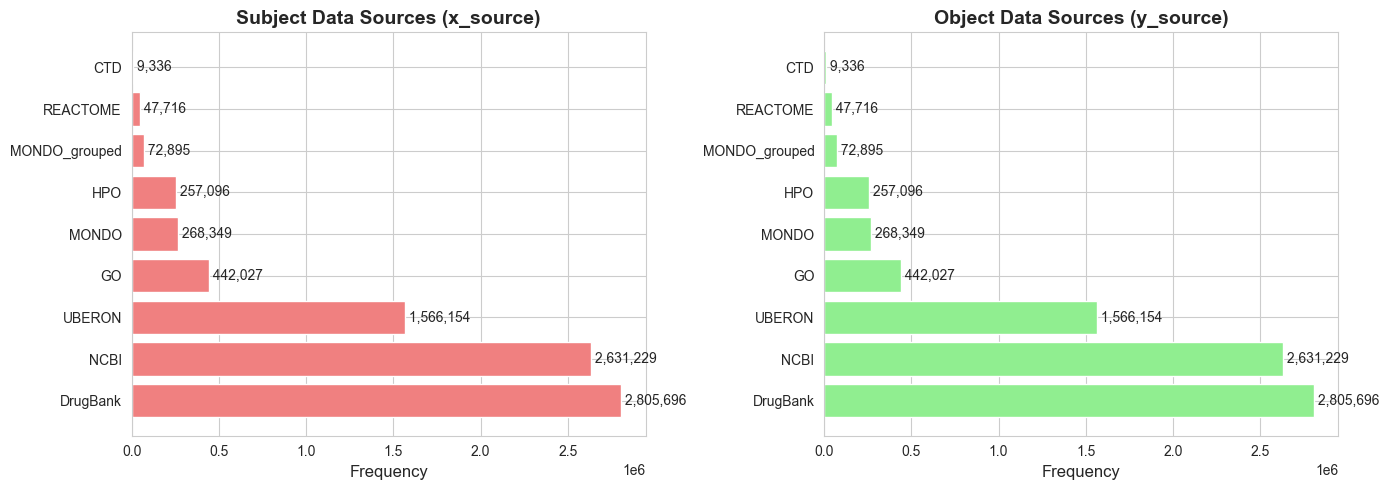

In [9]:
# Analyze data sources
x_source_counts = df['x_source'].value_counts()
y_source_counts = df['y_source'].value_counts()

print("Subject Data Sources (x_source):")
print(x_source_counts)
print("\nObject Data Sources (y_source):")
print(y_source_counts)

# Visualize data sources
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# x_source
axes[0].barh(range(len(x_source_counts)), x_source_counts.values, color='lightcoral')
axes[0].set_yticks(range(len(x_source_counts)))
axes[0].set_yticklabels(x_source_counts.index)
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_title('Subject Data Sources (x_source)', fontsize=14, fontweight='bold')
for i, v in enumerate(x_source_counts.values):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=10)

# y_source
axes[1].barh(range(len(y_source_counts)), y_source_counts.values, color='lightgreen')
axes[1].set_yticks(range(len(y_source_counts)))
axes[1].set_yticklabels(y_source_counts.index)
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_title('Object Data Sources (y_source)', fontsize=14, fontweight='bold')
for i, v in enumerate(y_source_counts.values):
    axes[1].text(v, i, f' {v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Data Source Analysis

Subject Entity Types (x_type):
x_type
drug                  2805696
gene/protein          2631229
anatomy               1566154
disease                341244
effect/phenotype       257096
biological_process     252202
molecular_function      96723
cellular_component      93102
pathway                 47716
exposure                 9336
Name: count, dtype: int64

Object Entity Types (y_type):
y_type
drug                  2805696
gene/protein          2631229
anatomy               1566154
disease                341244
effect/phenotype       257096
biological_process     252202
molecular_function      96723
cellular_component      93102
pathway                 47716
exposure                 9336
Name: count, dtype: int64


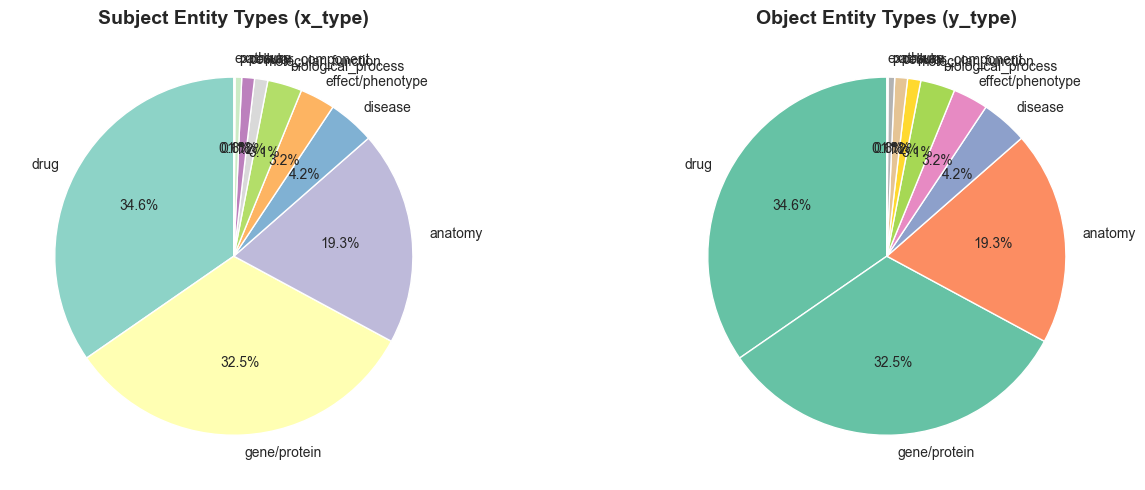


Unique x_types: 10
Unique y_types: 10


In [5]:
# Analyze entity types
x_type_counts = df['x_type'].value_counts()
y_type_counts = df['y_type'].value_counts()

print("Subject Entity Types (x_type):")
print(x_type_counts)
print("\nObject Entity Types (y_type):")
print(y_type_counts)

# Visualize entity types
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# x_type distribution
colors1 = plt.cm.Set3(np.linspace(0, 1, len(x_type_counts)))
axes[0].pie(x_type_counts.values, labels=x_type_counts.index, autopct='%1.1f%%',
            colors=colors1, startangle=90)
axes[0].set_title('Subject Entity Types (x_type)', fontsize=14, fontweight='bold')

# y_type distribution
colors2 = plt.cm.Set2(np.linspace(0, 1, len(y_type_counts)))
axes[1].pie(y_type_counts.values, labels=y_type_counts.index, autopct='%1.1f%%',
            colors=colors2, startangle=90)
axes[1].set_title('Object Entity Types (y_type)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nUnique x_types: {len(x_type_counts)}")
print(f"Unique y_types: {len(y_type_counts)}")

## 3. Entity Type Analysis

Number of unique relations: 30

Top 15 Relations by frequency:
relation
anatomy_protein_present       3036406
drug_drug                     2672628
protein_protein                642150
disease_phenotype_positive     300634
bioprocess_protein             289610
cellcomp_protein               166804
disease_protein                160822
molfunc_protein                139060
drug_effect                    129568
bioprocess_bioprocess          105772
pathway_protein                 85292
disease_disease                 64388
contraindication                61350
drug_protein                    51306
anatomy_protein_absent          39774
Name: count, dtype: int64


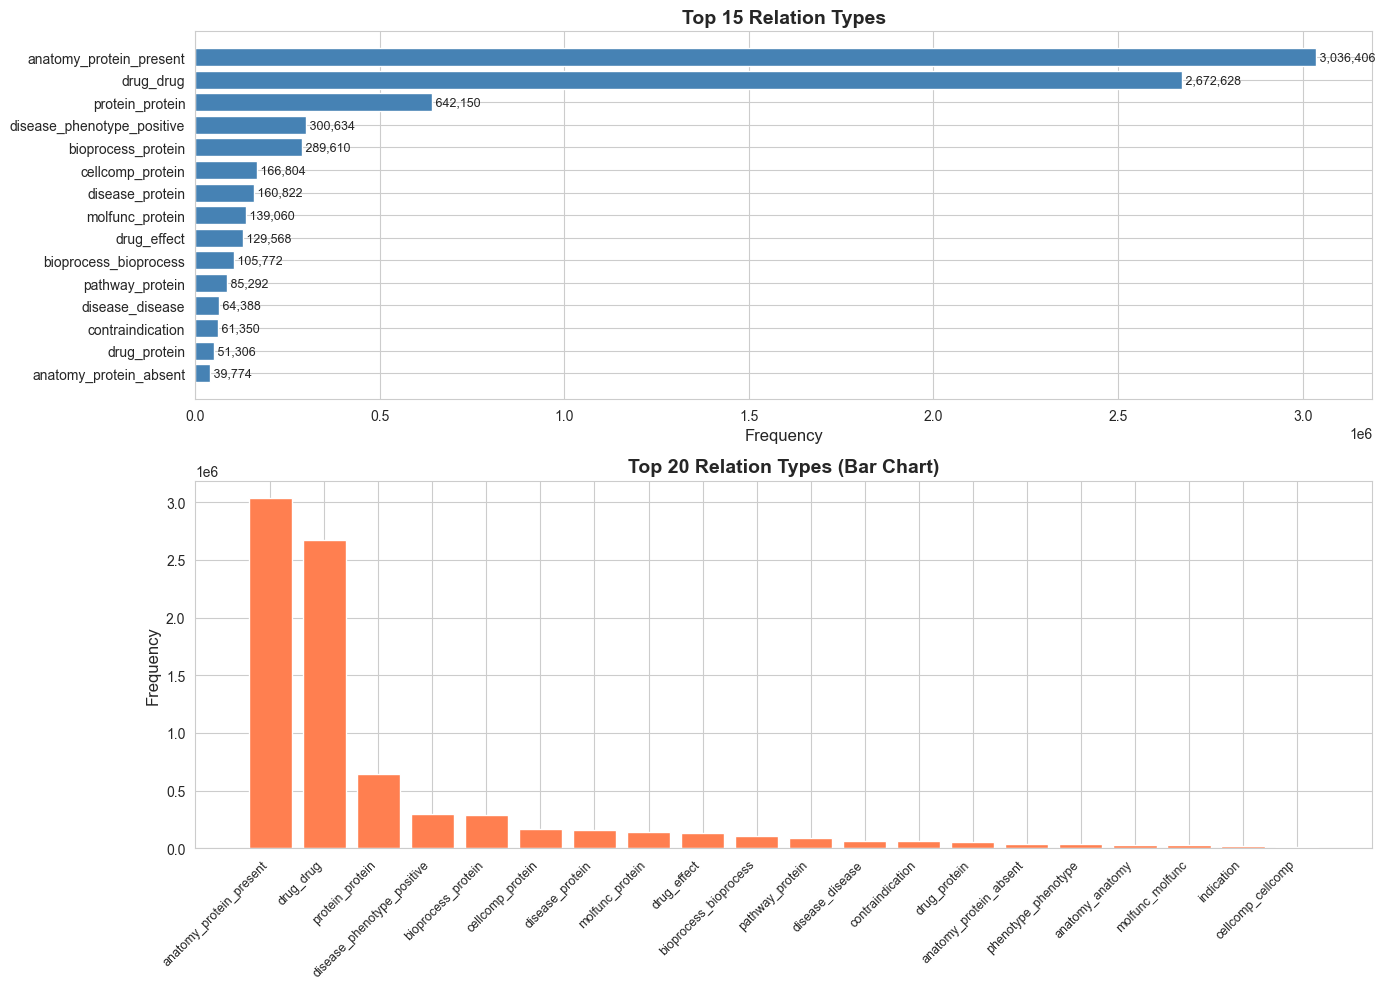


Total unique relations: 30


In [4]:
# Analyze relation types
relation_counts = df['relation'].value_counts()
print(f"Number of unique relations: {len(relation_counts)}")
print("\nTop 15 Relations by frequency:")
print(relation_counts.head(15))

# Visualize top relations
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 15 relations
top_relations = relation_counts.head(15)
axes[0].barh(range(len(top_relations)), top_relations.values, color='steelblue')
axes[0].set_yticks(range(len(top_relations)))
axes[0].set_yticklabels(top_relations.index)
axes[0].set_xlabel('Frequency', fontsize=12)
axes[0].set_title('Top 15 Relation Types', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top_relations.values):
    axes[0].text(v, i, f' {v:,}', va='center', fontsize=9)

# Distribution of relation types (Top 20)
top_20_relations = relation_counts.head(20)
axes[1].bar(range(len(top_20_relations)), top_20_relations.values, color='coral')
axes[1].set_xticks(range(len(top_20_relations)))
axes[1].set_xticklabels(top_20_relations.index, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Top 20 Relation Types (Bar Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal unique relations: {len(relation_counts)}")

## 2. Relationship Type Analysis

In [3]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing)
print("\n" + "="*80)

# Check for duplicate rows
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate rows (ignoring index): {df.duplicated(keep=False).sum()}")

Missing Values:
relation            0
display_relation    0
x_index             0
x_id                0
x_type              0
x_name              0
x_source            0
y_index             0
y_id                0
y_type              0
y_name              0
y_source            0
dtype: int64

Total rows: 8100498
Duplicate rows: 0
Duplicate rows (ignoring index): 0


In [2]:
# Load the dataset
kg_path = '/Users/bhargav/Desktop/hackrare2026/datasets/kg.csv'
df = pd.read_csv(kg_path)

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("First few rows:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())
print("\n" + "="*80)
print("Basic Statistics:")
print(df.describe())

Dataset Shape: (8100498, 12)

First few rows:
          relation display_relation  x_index  x_id        x_type  x_name  \
0  protein_protein              ppi        0  9796  gene/protein  PHYHIP   
1  protein_protein              ppi        1  7918  gene/protein  GPANK1   
2  protein_protein              ppi        2  8233  gene/protein   ZRSR2   
3  protein_protein              ppi        3  4899  gene/protein    NRF1   
4  protein_protein              ppi        4  5297  gene/protein   PI4KA   

  x_source  y_index   y_id        y_type  y_name y_source  
0     NCBI     8889  56992  gene/protein   KIF15     NCBI  
1     NCBI     2798   9240  gene/protein   PNMA1     NCBI  
2     NCBI     5646  23548  gene/protein   TTC33     NCBI  
3     NCBI    11592  11253  gene/protein  MAN1B1     NCBI  
4     NCBI     2122   8601  gene/protein   RGS20     NCBI  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8100498 entries, 0 to 8100497
Data columns (total 12 columns):
 #   Column         

## 1. Data Loading and Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


# Exploratory Data Analysis - PrimeKG Dataset

This notebook provides comprehensive exploratory data analysis of the PrimeKG knowledge graph (kg.csv) with detailed visualizations.